cell 1: imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [14]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current working directory:
C:\Users\welcome\Desktop\restaurant-sales-forecasting-system\minorProj

Files here:
['.env', '.gitignore', 'config', 'data', 'notebooks', 'requirements.txt', 'src', 'venv']


cell 2: loads data

In [15]:
import os

print("CURRENT DIR:")
print(os.getcwd())

print("\nFILES HERE:")
print(os.listdir())

print("\nDATA RAW EXISTS?:")
print(os.path.exists("data/raw"))

print("\nTRYING PATH:")
print(os.path.exists("../data/raw"))

CURRENT DIR:
C:\Users\welcome\Desktop\restaurant-sales-forecasting-system\minorProj

FILES HERE:
['.env', '.gitignore', 'config', 'data', 'notebooks', 'requirements.txt', 'src', 'venv']

DATA RAW EXISTS?:
True

TRYING PATH:
False


In [16]:
from pathlib import Path
import pandas as pd

data_path = Path("../data/raw/restaurant_dataset.csv").resolve()

print(data_path)
print(data_path.exists())

df = pd.read_csv("data/raw/restaurant_dataset.csv")

C:\Users\welcome\Desktop\restaurant-sales-forecasting-system\data\raw\restaurant_dataset.csv
False


cell 3: basic info

In [17]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (9551, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to orde

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


cell 4: restaurant distribution by city

C:\Users\welcome\Desktop\restaurant-sales-forecasting-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


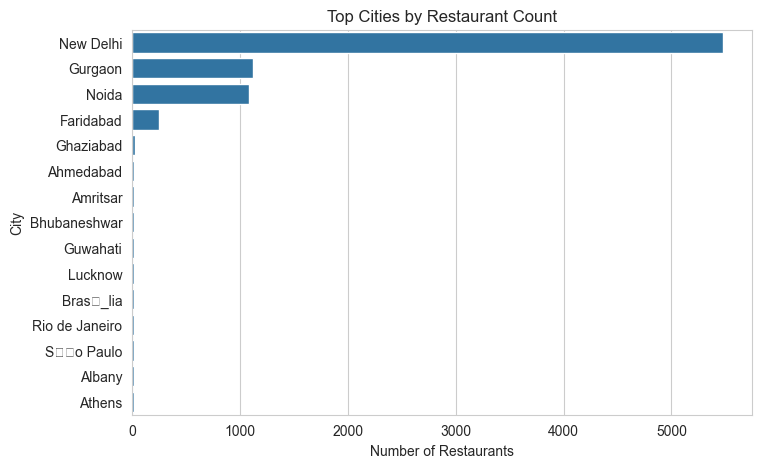

In [18]:
city_col = [c for c in df.columns if "city" in c.lower()][0]

city_counts = df[city_col].value_counts().head(15)

sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title("Top Cities by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

cell 5: cusisine distribution

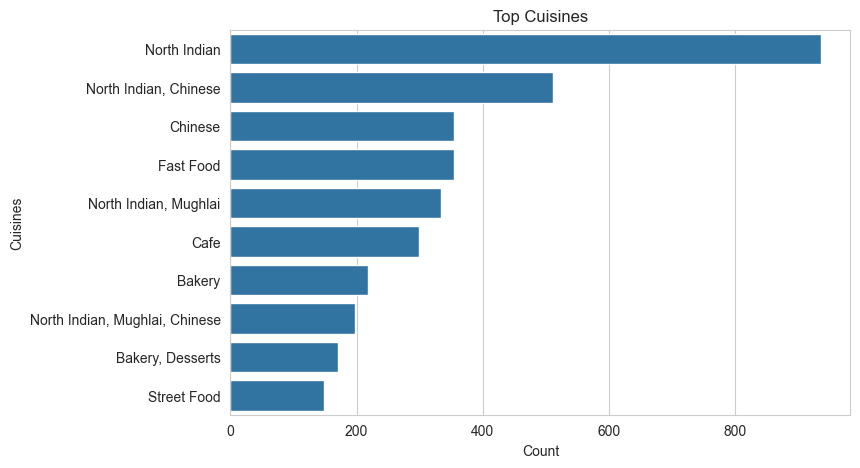

In [19]:
cuisine_col = [c for c in df.columns if "cuisine" in c.lower()][0]

cuisine_counts = df[cuisine_col].value_counts().head(10)

sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index)
plt.title("Top Cuisines")
plt.xlabel("Count")
plt.show()

cell 6: price range vs rating correlation

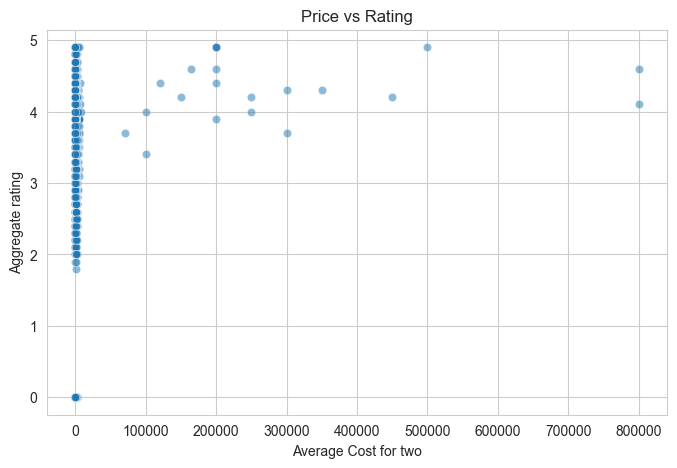

Correlation:                       Average Cost for two  Aggregate rating
Average Cost for two              1.000000          0.051792
Aggregate rating                  0.051792          1.000000


In [20]:
rating_col = [c for c in df.columns if "rating" in c.lower()][0]
price_col = [c for c in df.columns if "price" in c.lower() or "cost" in c.lower()][0]

sns.scatterplot(data=df, x=price_col, y=rating_col, alpha=0.5)
plt.title("Price vs Rating")
plt.show()

print("Correlation:", df[[price_col, rating_col]].corr())

cell 7: geographic clustering (if lat/long exist)

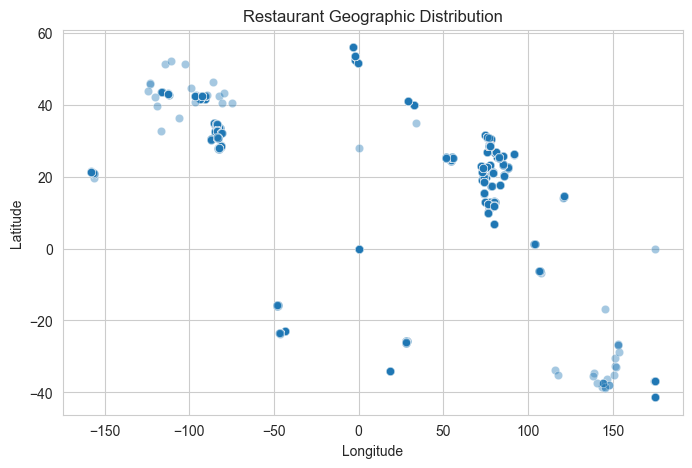

In [21]:
lat_cols = [c for c in df.columns if "lat" in c.lower()]
lon_cols = [c for c in df.columns if "lon" in c.lower()]

if lat_cols and lon_cols:
    sns.scatterplot(
        x=df[lon_cols[0]],
        y=df[lat_cols[0]],
        alpha=0.4
    )
    plt.title("Restaurant Geographic Distribution")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
else:
    print("Latitude/Longitude not found → skipping map")

cell 8: rating distribution

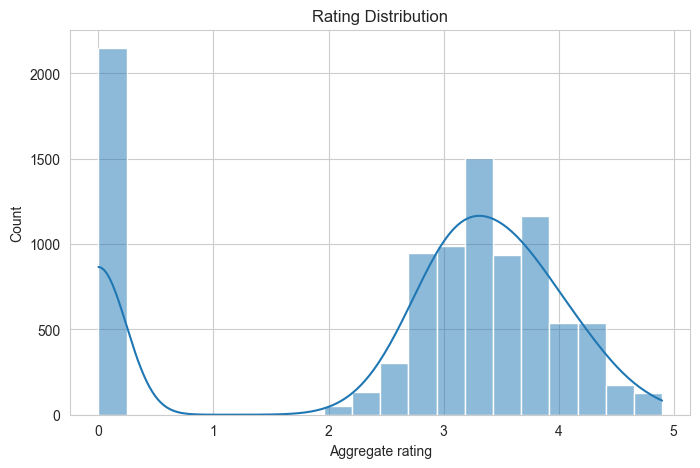

In [22]:
sns.histplot(df[rating_col], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

cell 9: missing value heatmap

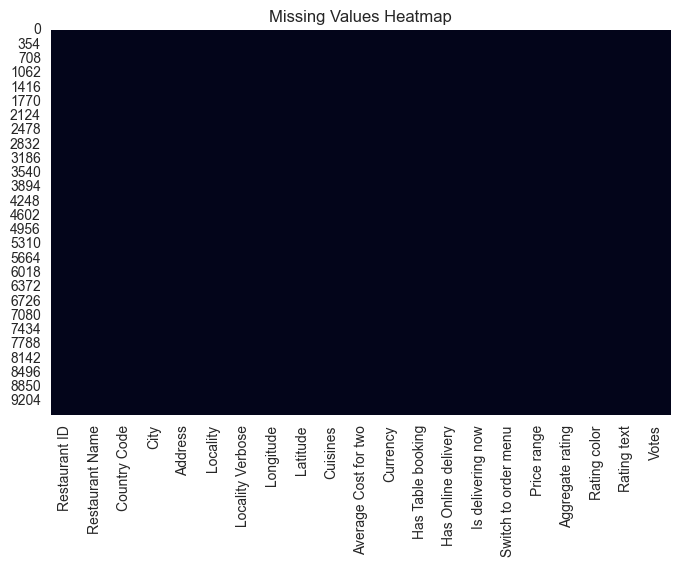

In [23]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()